# Real-world task I: one-step prediction of the Santa Fe far-infrared laser intensity

## Statement of the problem
Experimental chaotic data (Santa Fe competition set A, far-infrared NH$_3$ laser, 10,093 samples; first 1,000 used, Mackey–Glass split, one-step target). The intensity collapses are a strongly nonlinear feature: does the emitter resolve them, and do the squeezing controls help?

**Protocol.** Coarse scan, gradient descent (4 starts), refabrication grid extended to $\epsilon=0.5$, Fock check at the optimum, transfer to the segments starting at samples 2,500 and 5,000, reservoir-free baselines, amplifying-branch scan. Script `run_laser.py` (~15 min); the series comes from `reservoirpy.datasets.santafe_laser`.

In [1]:
import os, sys, subprocess, numpy as np
CODE = os.path.abspath(os.path.join(os.getcwd(), '..', 'code')); sys.path.insert(0, CODE); os.chdir(CODE); os.environ['OMP_NUM_THREADS'] = '1'
import matplotlib; matplotlib.use('Agg'); import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
from common import *
import make_figs
RUN = False   # set True to recompute the data for this notebook (see the "Compute" section for the cost)
def show(pdf, dpi=110):
    """Render a figure PDF from paper/figs inline."""
    base = '/tmp/' + os.path.basename(pdf)[:-4]; subprocess.run(['pdftoppm', '-r', str(dpi), '-png', '-singlefile', pdf, base], check=True); display(Image(filename=base + '.png'))
def ld(name):
    p = os.path.join(DATA, name); return np.load(p, allow_pickle=True) if os.path.exists(p) else None


In [2]:
if RUN: subprocess.run(['python3', 'run_laser.py'])
ls_ = ld('laser.npz'); L0 = ls_['L3'][0, 0, 0]; Lb = float(ls_['bestL'])
print('unsqueezed: L0 = %.1f, NRMSE %.3f;  baselines:' % (L0, ls_['N3'][0, 0, 0]), [(r[0], round(float(r[2]), 3)) for r in ls_['base']])
print('squeezed optimum (%.2f, %.2f, %.2f): L = %.1f (%.0f%%), NRMSE %.3f (Nc=16: %.3f), photons %.2f' % (*ls_['best'], Lb, 100 * (1 - Lb / L0), ls_['conv'][0, 1], ls_['conv'][2, 1], ls_['conv'][2, 2]))
print('refabrication best %.0f%%; recovered %.0f%%; amplifying branch best %.0f%%' % (100 * (1 - ls_['refab'].min() / L0), 100 * (L0 - Lb) / (L0 - ls_['refab'].min()), 100 * (1 - ls_['flipL3'].min() / L0)))
print('transfer to later segments:', (100 * (1 - ls_['seeds'][:, 1] / ls_['seeds'][:, 0])).round(0), '% reductions')

unsqueezed: L0 = 230.1, NRMSE 0.313;  baselines: [('ols4', 0.406), ('ols10', 0.342), ('quad10', 0.09), ('esn100', 0.049)]
squeezed optimum (0.46, 0.48, 2.81): L = 81.1 (65%), NRMSE 0.183 (Nc=16: 0.184), photons 0.86
refabrication best 83%; recovered 78%; amplifying branch best 58%
transfer to later segments: [65. 66.] % reductions


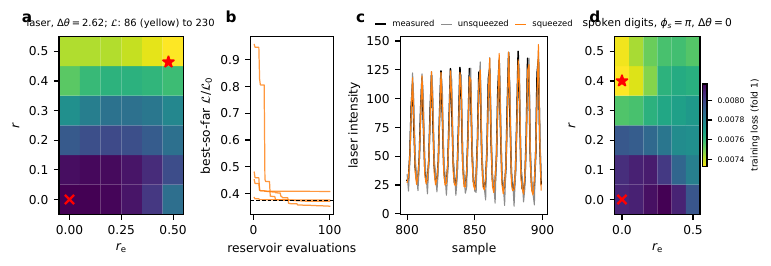

In [3]:
make_figs.fig_real(); show('paper/figs/fig_real.pdf')

**Figure 5a–c.** Landscape slice, gradient-descent curves, held-out prediction traces. The unsqueezed device already beats linear regression on ten delays; squeezing lowers the loss by 65% (NRMSE 0.31 → 0.18) on the de-amplifying branch — the laser rewards the phase-sensitive emitter response, not a larger drive (Lorenz is the mirror case).